In [0]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
spark = SparkSession.builder.appName("EDA").getOrCreate()

In [0]:
appointments_data = [ 
(1001, "Hyderabad", "Cardiology", "Apollo", 1500, "Completed"), 
(1002, "Bangalore", "Neurology", "Yashoda", 2200, "Completed"), 
(1003, "Mumbai", "Dermatology", "Care", 900, "Pending"), 
(1004, "Delhi", "Orthopedics", "Max", 2500, "Completed"), 
(1005, "Chennai", "Pediatrics", "Apollo", 1200, "Cancelled"), 
(1006, "Hyderabad", "Cardiology", "Care", 3000, "Completed"), 
(1007, "Bangalore", "Dermatology", "Apollo", 1000, "Completed"), 
(1008, "Mumbai", "Neurology", "Max", 2600, "Pending"), 
(1009, "Delhi", "Cardiology", "Yashoda", 2800, "Completed"), 
(1010, "Chennai", "Orthopedics", "Care", 2400, "Completed"), 
(1011, "Hyderabad", "Pediatrics", "Apollo", 1100, "Completed"), 
(1012, "Bangalore", "Cardiology", "Max", 3200, "Completed"), 
(1013, "Mumbai", "Pediatrics", "Yashoda", 1300, "Cancelled"), 
(1014, "Delhi", "Neurology", "Apollo", 2700, "Completed"), 
(1015, "Chennai", "Dermatology", "Care", 950, "Pending") 
]

columns = [ 
"appointment_id", 
"city", 
"department", 
"hospital", 
"consultation_fee", 
"status" 
]

df = spark.createDataFrame(appointments_data, columns) 
display(df) 

appointment_id,city,department,hospital,consultation_fee,status
1001,Hyderabad,Cardiology,Apollo,1500,Completed
1002,Bangalore,Neurology,Yashoda,2200,Completed
1003,Mumbai,Dermatology,Care,900,Pending
1004,Delhi,Orthopedics,Max,2500,Completed
1005,Chennai,Pediatrics,Apollo,1200,Cancelled
1006,Hyderabad,Cardiology,Care,3000,Completed
1007,Bangalore,Dermatology,Apollo,1000,Completed
1008,Mumbai,Neurology,Max,2600,Pending
1009,Delhi,Cardiology,Yashoda,2800,Completed
1010,Chennai,Orthopedics,Care,2400,Completed


Exercises

In [0]:
# Bar Chart: Revenue by city
city_revenue = df.groupBy("city").agg(sum("consultation_fee").alias("total_revenue")).orderBy(col("total_revenue").desc())
display(city_revenue)

city,total_revenue
Delhi,8000
Bangalore,6400
Hyderabad,5600
Mumbai,4800
Chennai,4550


Databricks visualization. Run in Databricks to view.

In [0]:
# Bar Chart: Revenue by Department
dept_revenue = df.groupBy("department").agg(sum("consultation_fee").alias("total_revenue")).orderBy(col("total_revenue").desc())
display(dept_revenue)

department,total_revenue
Cardiology,10500
Neurology,7500
Orthopedics,4900
Pediatrics,3600
Dermatology,2850


Databricks visualization. Run in Databricks to view.

In [0]:
# Pie Chart: Appointment Status
appointment_status = df.groupBy("status").count()
display(appointment_status)

status,count
Completed,10
Pending,3
Cancelled,2


Databricks visualization. Run in Databricks to view.

In [0]:
# Horizontal Bar: Revenue by Hospital
hosp_revenue = df.groupBy("hospital").agg(sum("consultation_fee").alias("total_revenue")).orderBy(col("total_revenue").desc())
display(hosp_revenue)

hospital,total_revenue
Max,8300
Apollo,7500
Care,7250
Yashoda,6300


Databricks visualization. Run in Databricks to view.

In [0]:
# Scatter Plot: Appointment ID vs Fee
id_fee = df.select("appointment_id", "consultation_fee")
display(id_fee)

appointment_id,consultation_fee
1001,1500
1002,2200
1003,900
1004,2500
1005,1200
1006,3000
1007,1000
1008,2600
1009,2800
1010,2400


Databricks visualization. Run in Databricks to view.

In [0]:
# Line Chart: Fee Trend by Appointment
fee_trend = df.select("appointment_id", "consultation_fee").orderBy("appointment_id")
display(fee_trend)

appointment_id,consultation_fee
1001,1500
1002,2200
1003,900
1004,2500
1005,1200
1006,3000
1007,1000
1008,2600
1009,2800
1010,2400


Databricks visualization. Run in Databricks to view.

In [0]:
# Bar chart for appointment count by city
cit_cnt = df.groupBy("city").count()
display(cit_cnt)

city,count
Hyderabad,3
Bangalore,3
Mumbai,3
Delhi,3
Chennai,3


Databricks visualization. Run in Databricks to view.

In [0]:
# Bar chart for appointment count by department
apt_cnt = df.groupBy("department").count()
display(apt_cnt)

department,count
Cardiology,4
Neurology,3
Dermatology,3
Orthopedics,2
Pediatrics,3


Databricks visualization. Run in Databricks to view.

In [0]:
# Pie chart for status distribution
status_cnt = df.groupBy("status").count()
display(status_cnt)

status,count
Completed,10
Pending,3
Cancelled,2


Databricks visualization. Run in Databricks to view.

In [0]:
# Chart only for Completed appointments
completed_df = df.filter(col("status")=="Completed")
display(completed_df)

appointment_id,city,department,hospital,consultation_fee,status
1001,Hyderabad,Cardiology,Apollo,1500,Completed
1002,Bangalore,Neurology,Yashoda,2200,Completed
1004,Delhi,Orthopedics,Max,2500,Completed
1006,Hyderabad,Cardiology,Care,3000,Completed
1007,Bangalore,Dermatology,Apollo,1000,Completed
1009,Delhi,Cardiology,Yashoda,2800,Completed
1010,Chennai,Orthopedics,Care,2400,Completed
1011,Hyderabad,Pediatrics,Apollo,1100,Completed
1012,Bangalore,Cardiology,Max,3200,Completed
1014,Delhi,Neurology,Apollo,2700,Completed


Databricks visualization. Run in Databricks to view.

In [0]:
# Revenue chart after excluding Cancelled appointments
existing_df = df.filter(col("status")!="Cancelled").groupBy(col("city")).agg(sum("consultation_fee").alias("total_revenue"))
display(existing_df)

city,total_revenue
Hyderabad,5600
Bangalore,6400
Mumbai,3500
Delhi,8000
Chennai,3350


Databricks visualization. Run in Databricks to view.

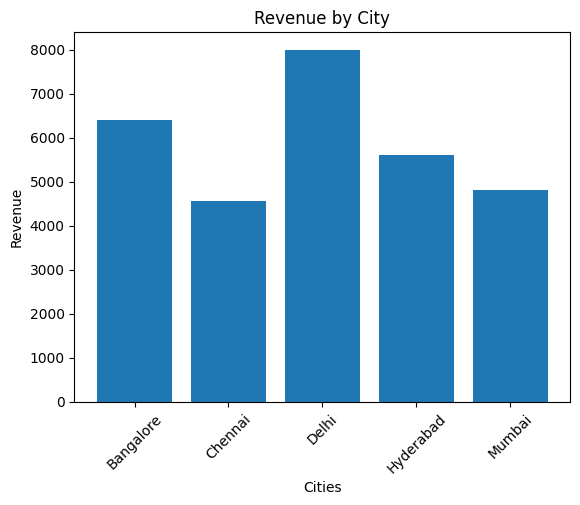

<Figure size 1000x600 with 0 Axes>

In [0]:
# Using plt (Questions: 11-15)
import matplotlib.pyplot as plt
import pandas as pd
pdf = df.toPandas()
city_rev = pdf.groupby("city")["consultation_fee"].sum().reset_index()
plt.bar(city_rev["city"], city_rev["consultation_fee"])
plt.xticks(rotation=45)
plt.title("Revenue by City")
plt.xlabel("Cities")
plt.ylabel("Revenue")
plt.figure(figsize=(10, 6))
plt.show()

Top 3 Cities by Revenue


city,Revenue
Delhi,8000
Bangalore,6400
Hyderabad,5600


Top 3 departments by Revenue


department,Revenue
Cardiology,10500
Neurology,7500
Orthopedics,4900


Lowest revenue hospital
+--------+-------+
|hospital|Revenue|
+--------+-------+
| Yashoda|   6300|
+--------+-------+

Pie chart showing hospital-wise appointment share


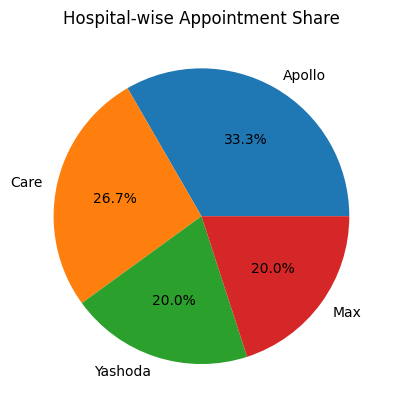

<Figure size 600x600 with 0 Axes>

In [0]:
print("Top 3 Cities by Revenue")
top_3_cities = df.groupBy("city").agg(sum("consultation_fee").alias("Revenue")).orderBy(desc("Revenue")).limit(3)
display(top_3_cities)

print("Top 3 departments by Revenue")
top_3_departments = df.groupBy("department").agg(sum("consultation_fee").alias("Revenue")).orderBy(desc("Revenue")).limit(3)
display(top_3_departments)

print("Lowest revenue hospital")
df.groupBy("hospital").agg(sum("consultation_fee").alias("Revenue")).orderBy("Revenue").limit(1).show()

print("Pie chart showing hospital-wise appointment share")
hosp_share = pdf["hospital"].value_counts()
plt.pie(hosp_share, labels=hosp_share.index, autopct='%1.1f%%')
plt.title("Hospital-wise Appointment Share")
plt.figure(figsize=(6, 6))
plt.show()

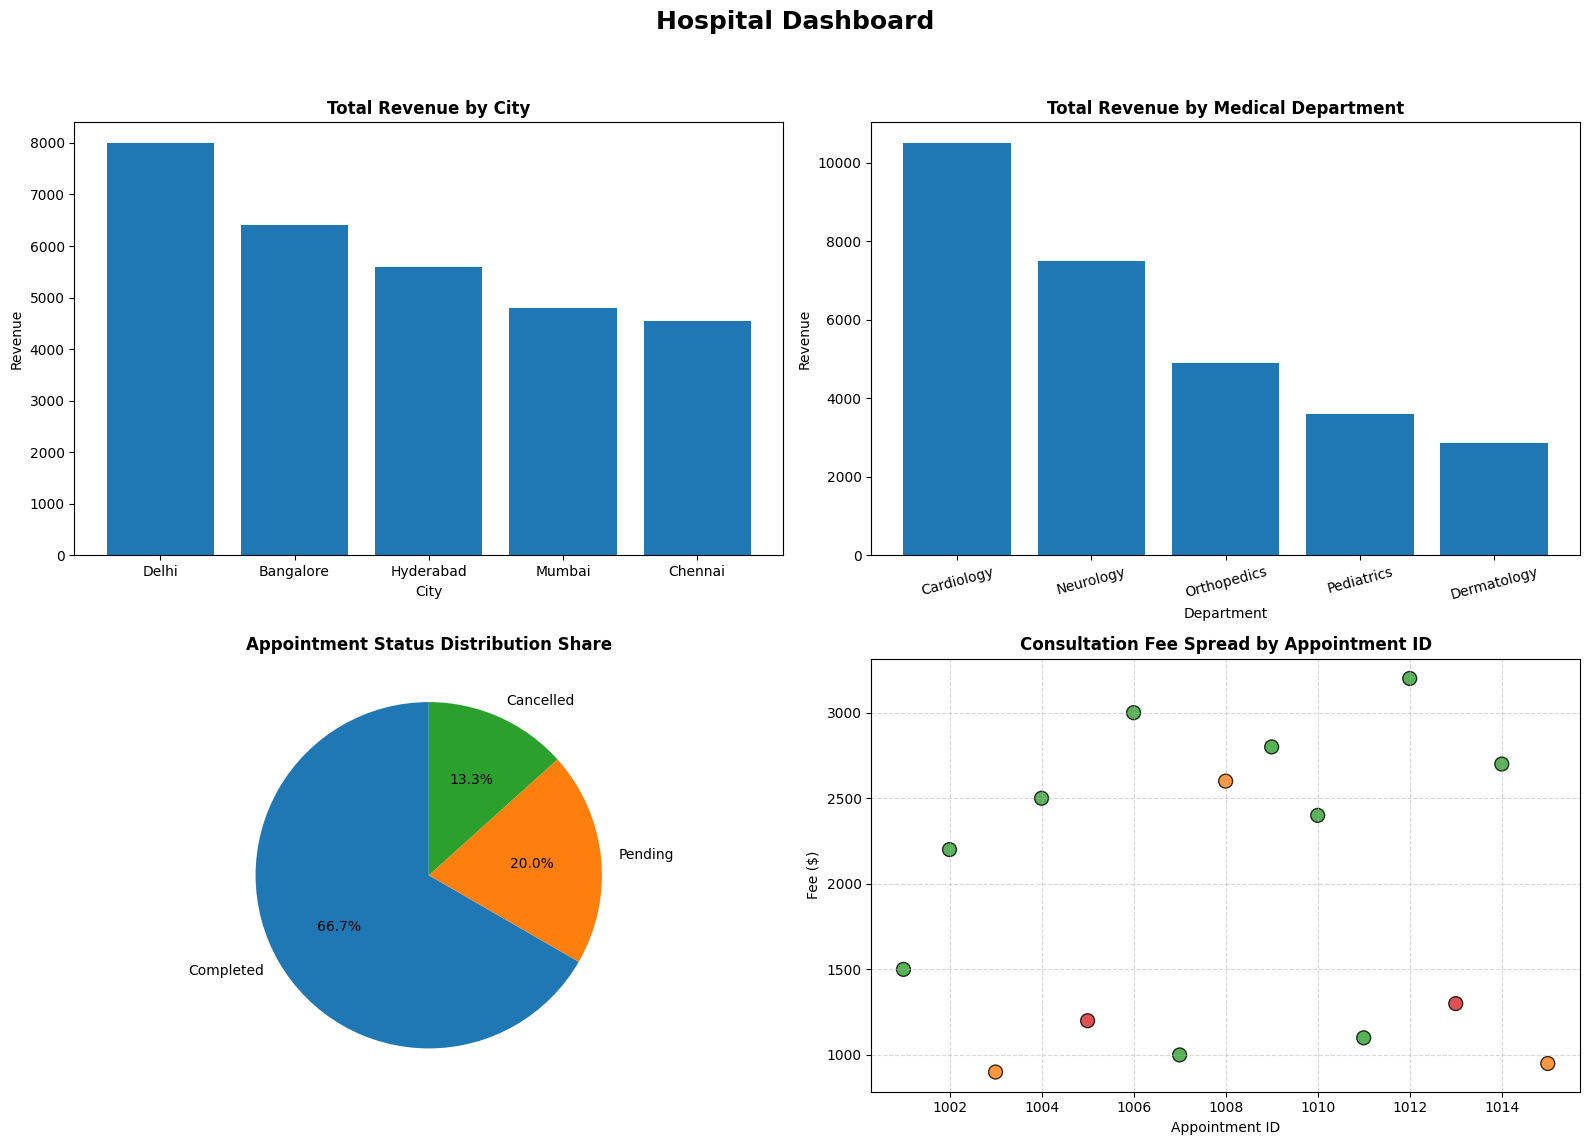

In [0]:
# Final EDA Dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Hospital Dashboard", fontsize=18, fontweight='bold')
# Revenue by City (Bar Chart) 
city_rev_data = pdf.groupby("city")["consultation_fee"].sum().sort_values(ascending=False)
axes[0,0].bar(city_rev_data.index, city_rev_data.values)
axes[0,0].set_title("Total Revenue by City", fontsize=12, fontweight='bold')
axes[0,0].set_xlabel("City")
axes[0,0].set_ylabel("Revenue")

# Revenue by Department (Bar Chart) 
dept_rev_data = pdf.groupby("department")["consultation_fee"].sum().sort_values(ascending=False)
axes[0,1].bar(dept_rev_data.index, dept_rev_data.values)
axes[0,1].set_title("Total Revenue by Medical Department", fontsize=12, fontweight='bold')
axes[0,1].set_xlabel("Department")
axes[0,1].set_ylabel("Revenue")
axes[0,1].tick_params(axis='x', rotation=15)

# Appointment Status (Pie Chart)
status_counts = pdf["status"].value_counts()
axes[1,0].pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%', startangle=90)
axes[1,0].set_title("Appointment Status Distribution Share", fontsize=12, fontweight='bold')

# Consultation Fee Trends (Scatter Plot)
status_colors = {'Completed': '#2ca02c', 'Pending': '#ff7f0e', 'Cancelled': '#d62728'}
colors = pdf['status'].map(status_colors)

scatter = axes[1,1].scatter(pdf["appointment_id"], pdf["consultation_fee"], c=colors, s=100, alpha=0.8, edgecolors='black')
axes[1,1].set_title("Consultation Fee Spread by Appointment ID", fontsize=12, fontweight='bold')
axes[1,1].set_xlabel("Appointment ID")
axes[1,1].set_ylabel("Fee ($)")
axes[1,1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()